In [2]:
import pandas as pd

df = pd.read_csv('../data/raw/vanet_traffic_data.csv')

print("Shape:", df.shape)
print("\n--- Dtypes ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

print("\n--- Label Distribution ---")
print(df['label'].value_counts())

print("\n--- Sample Rows ---")
print(df.head())

Shape: (195714, 27)

--- Dtypes ---
timestamp                         object
road_segment_id                   object
avg_speed_kmph                   float64
density_veh_per_km               float64
avg_wait_time_s                  float64
occupancy_pct                    float64
flow_veh_per_hr                  float64
queue_length_veh                 float64
avg_accel_ms2                    float64
heading_deg                      float64
signal_state_num                 float64
incident_num                     float64
temp_c                           float64
visibility_km                    float64
rain_intensity_mmph              float64
channel_busy_ratio_pct           float64
msg_rate_hz                      float64
avg_comm_delay_ms                float64
rssi_dbm                         float64
packet_loss_pct                  float64
speed_density_ratio              float64
congestion_pressure              float64
wireless_congestion_intensity    float64
throughput_per_queued

       avg_speed_kmph  density_veh_per_km  avg_wait_time_s  occupancy_pct  \
count   195714.000000       195714.000000    195714.000000  195714.000000   
mean        40.113615           42.531785        41.490966      48.635799   
std         23.680900           29.323898        41.245668      31.320898   
min          1.030000            1.100000        -2.630000       1.390000   
25%         23.740000           12.010000         7.020000      12.020000   
50%         43.710000           31.910000        21.935000      41.640000   
75%         68.010000           61.940000        52.570000      71.590000   
max         77.970000          101.200000       137.870000     103.490000   

       flow_veh_per_hr  queue_length_veh  avg_accel_ms2    heading_deg  \
count    195714.000000     195714.000000  195714.000000  195714.000000   
mean       1217.380428         20.595787       0.087940     141.391571   
std         693.234355         20.800210       0.664306      94.558893   
min       

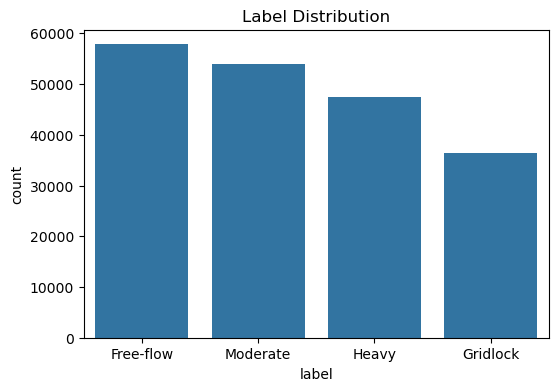

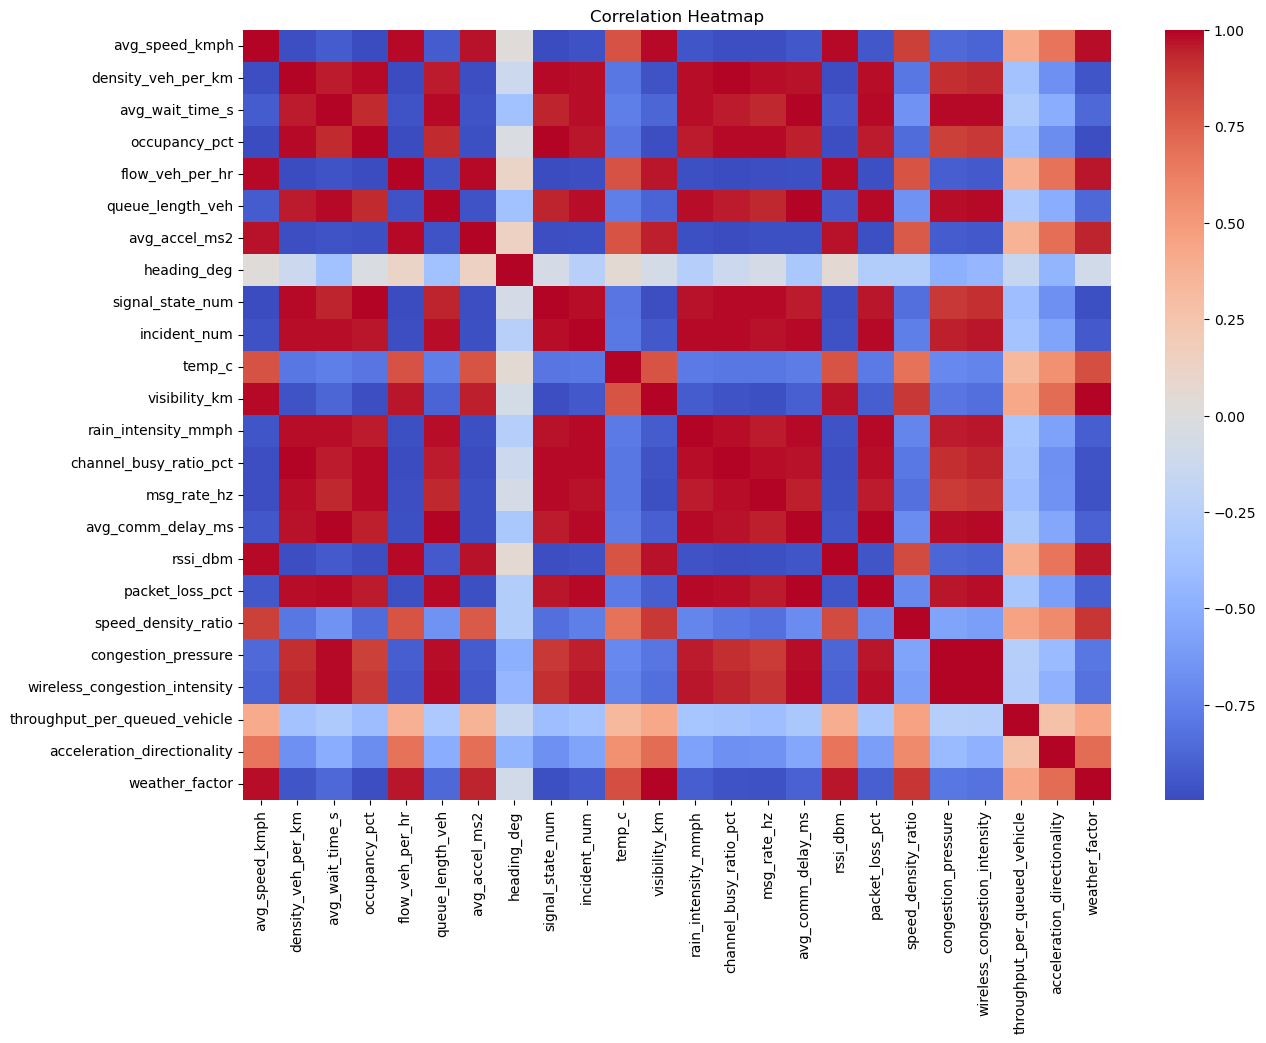


Unique road_segment_id count: 500

Timestamp range: 2025-09-28 00:00:00 to 2025-09-30 12:53:47


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv('../data/raw/vanet_traffic_data.csv')

os.makedirs('../reports/figures', exist_ok=True)

# 1. Statistical summary
print(df.describe())

# 2. Label distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, order=df['label'].value_counts().index)
plt.title('Label Distribution')
plt.savefig('../reports/figures/label_distribution.png')
plt.show()

# 3. Correlation heatmap (numeric features only)
numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.savefig('../reports/figures/correlation_heatmap.png')
plt.show()

# 4. Unique road segments
print("\nUnique road_segment_id count:", df['road_segment_id'].nunique())

# 5. Timestamp range
df['timestamp'] = pd.to_datetime(df['timestamp'])
print("\nTimestamp range:", df['timestamp'].min(), "to", df['timestamp'].max())

In [4]:
# Get highly correlated pairs (|corr| > 0.85)
corr_matrix = numeric_df.corr().abs()
upper = corr_matrix.where(pd.np.triu(pd.np.ones(corr_matrix.shape), k=1).astype(bool)) if hasattr(pd, 'np') else corr_matrix.where(
    __import__('numpy').triu(__import__('numpy').ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = upper.stack().reset_index()
high_corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'] > 0.85].sort_values(by='Correlation', ascending=False)

print(high_corr_pairs.to_string(index=False))

             Feature 1                     Feature 2  Correlation
         visibility_km                weather_factor     0.998304
       flow_veh_per_hr        channel_busy_ratio_pct     0.995980
         occupancy_pct              signal_state_num     0.994986
    density_veh_per_km               flow_veh_per_hr     0.994216
       avg_wait_time_s             avg_comm_delay_ms     0.994033
       flow_veh_per_hr              signal_state_num     0.993873
        avg_speed_kmph              signal_state_num     0.993621
        avg_speed_kmph                 occupancy_pct     0.993253
     avg_comm_delay_ms               packet_loss_pct     0.993118
    density_veh_per_km        channel_busy_ratio_pct     0.993007
   congestion_pressure wireless_congestion_intensity     0.992568
      queue_length_veh             avg_comm_delay_ms     0.992547
       avg_wait_time_s              queue_length_veh     0.991828
          incident_num             avg_comm_delay_ms     0.991440
      sign

In [5]:
# Correlation of each numeric feature with label (label encoded temporarily for this check)
from sklearn.preprocessing import LabelEncoder

le_temp = LabelEncoder()
label_encoded = le_temp.fit_transform(df['label'])

corr_with_label = numeric_df.corrwith(pd.Series(label_encoded, index=numeric_df.index)).abs().sort_values(ascending=False)
print(corr_with_label)

speed_density_ratio              0.672405
heading_deg                      0.596894
weather_factor                   0.431289
visibility_km                    0.413198
throughput_per_queued_vehicle    0.362692
avg_speed_kmph                   0.346567
occupancy_pct                    0.316867
signal_state_num                 0.291632
msg_rate_hz                      0.288956
rssi_dbm                         0.288834
temp_c                           0.236715
flow_veh_per_hr                  0.214319
channel_busy_ratio_pct           0.199435
density_veh_per_km               0.199237
incident_num                     0.170916
avg_accel_ms2                    0.168386
acceleration_directionality      0.155790
rain_intensity_mmph              0.119494
congestion_pressure              0.085812
avg_comm_delay_ms                0.072255
packet_loss_pct                  0.070759
wireless_congestion_intensity    0.067040
queue_length_veh                 0.030315
avg_wait_time_s                  0

In [8]:
 pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# 1. Prepare feature set (exclude non-numeric/target)
feature_cols = [col for col in df.columns if col not in ['timestamp', 'road_segment_id', 'label']]
X_vif = df[feature_cols].copy()

# 2. VIF Calculation
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)
print("--- VIF Scores (>10 = high multicollinearity) ---")
print(vif_data.to_string(index=False))

# 3. Feature Importance via Random Forest (quick baseline, not final model)
le_temp = LabelEncoder()
y_temp = le_temp.fit_transform(df['label'])

rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_temp.fit(X_vif, y_temp)

importance_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'Importance': rf_temp.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Random Forest Feature Importance ---")
print(importance_df.to_string(index=False))

--- VIF Scores (>10 = high multicollinearity) ---
                      Feature         VIF
                     rssi_dbm 3858.592878
               weather_factor 3442.890211
                visibility_km 3402.771928
                       temp_c 2927.744815
wireless_congestion_intensity 1558.614592
             signal_state_num 1518.758212
              packet_loss_pct 1310.600318
          congestion_pressure 1256.012076
            avg_comm_delay_ms 1157.432210
              flow_veh_per_hr 1038.908952
              avg_wait_time_s  874.565011
       channel_busy_ratio_pct  865.171569
           density_veh_per_km  860.073440
                occupancy_pct  592.193866
               avg_speed_kmph  519.863597
                  msg_rate_hz  462.901104
                  heading_deg  412.354609
                 incident_num  389.484182
             queue_length_veh  190.351050
                avg_accel_ms2  142.568482
          rain_intensity_mmph  127.572428
  acceleration_directional

In [7]:
df_fe = df.copy()

# --- Timestamp already converted earlier, but re-ensure dtype ---
df_fe['timestamp'] = pd.to_datetime(df_fe['timestamp'])

# 1. Extract time-based features
df_fe['hour'] = df_fe['timestamp'].dt.hour
df_fe['day_of_week'] = df_fe['timestamp'].dt.dayofweek  # 0=Monday
df_fe['is_weekend'] = df_fe['day_of_week'].isin([5, 6]).astype(int)

# 2. Rush hour flag (domain knowledge: 7-10 AM and 5-8 PM typical rush hours)
df_fe['is_rush_hour'] = df_fe['hour'].apply(lambda h: 1 if (7 <= h <= 10 or 17 <= h <= 20) else 0)

# 3. Clip physically-impossible negative values (from Step 2 findings)
df_fe['queue_length_veh'] = df_fe['queue_length_veh'].clip(lower=0)
df_fe['congestion_pressure'] = df_fe['congestion_pressure'].clip(lower=0)
df_fe['incident_num'] = df_fe['incident_num'].clip(lower=0)

# 4. Encode road_segment_id (frequency encoding - preserves info without high cardinality issue)
road_freq = df_fe['road_segment_id'].value_counts(normalize=True)
df_fe['road_segment_freq'] = df_fe['road_segment_id'].map(road_freq)

# 5. Verify new features
print(df_fe[['hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'road_segment_freq']].head())
print("\nRush hour distribution:\n", df_fe['is_rush_hour'].value_counts())
print("\nWeekend distribution:\n", df_fe['is_weekend'].value_counts())

   hour  day_of_week  is_weekend  is_rush_hour  road_segment_freq
0     4            0           0             0           0.001998
1     6            1           0             0           0.002003
2     5            0           0             0           0.001998
3    21            6           1             0           0.001998
4     0            6           1             0           0.001998

Rush hour distribution:
 is_rush_hour
0    129945
1     65769
Name: count, dtype: int64

Weekend distribution:
 is_weekend
0    113670
1     82044
Name: count, dtype: int64


In [8]:
print(df_fe['day_of_week'].value_counts().sort_index())
print(df_fe['timestamp'].dt.date.unique())

day_of_week
0    75623
1    38047
6    82044
Name: count, dtype: int64
[datetime.date(2025, 9, 29) datetime.date(2025, 9, 30)
 datetime.date(2025, 9, 28)]


In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Encode target label
le = LabelEncoder()
df_fe['label_encoded'] = le.fit_transform(df_fe['label'])

# Show mapping for reference
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# 2. Define final feature set (baseline - includes pending features for A/B testing)
final_features = [
    'speed_density_ratio', 'avg_speed_kmph', 'occupancy_pct', 'flow_veh_per_hr',
    'queue_length_veh', 'channel_busy_ratio_pct', 'packet_loss_pct',
    'congestion_pressure', 'wireless_congestion_intensity', 'incident_num',
    'throughput_per_queued_vehicle', 'weather_factor', 'signal_state_num',
    'heading_deg', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour',
    'road_segment_freq'
]

X = df_fe[final_features]
y = df_fe['label_encoded']

# 3. Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Verify split proportions
print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)
print("\nTrain label distribution:\n", y_train.value_counts(normalize=True))
print("\nTest label distribution:\n", y_test.value_counts(normalize=True))

Label mapping: {'Free-flow': np.int64(0), 'Gridlock': np.int64(1), 'Heavy': np.int64(2), 'Moderate': np.int64(3)}

Train shape: (156571, 19) Test shape: (39143, 19)

Train label distribution:
 label_encoded
0    0.295393
3    0.276003
2    0.242395
1    0.186209
Name: proportion, dtype: float64

Test label distribution:
 label_encoded
0    0.295378
3    0.276014
2    0.242393
1    0.186215
Name: proportion, dtype: float64


In [10]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, classification_report

# --- Baseline LightGBM ---
lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=4,
    random_state=42,
    n_jobs=-1
)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)

print("=== LightGBM (Baseline - All Features) ===")
print("Accuracy:", accuracy_score(y_test, lgb_preds))
print("F1 (macro):", f1_score(y_test, lgb_preds, average='macro'))
print(classification_report(y_test, lgb_preds, target_names=le.classes_))

# --- Baseline XGBoost ---
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("\n=== XGBoost (Baseline - All Features) ===")
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("F1 (macro):", f1_score(y_test, xgb_preds, average='macro'))
print(classification_report(y_test, xgb_preds, target_names=le.classes_))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015674 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3606
[LightGBM] [Info] Number of data points in the train set: 156571, number of used features: 19
[LightGBM] [Info] Start training from score -1.219448
[LightGBM] [Info] Start training from score -1.680883
[LightGBM] [Info] Start training from score -1.417187
[LightGBM] [Info] Start training from score -1.287345
=== LightGBM (Baseline - All Features) ===
Accuracy: 0.9906241218097744
F1 (macro): 0.9906166352483599
              precision    recall  f1-score   support

   Free-flow       0.99      1.00      0.99     11562
    Gridlock       0.99      0.99      0.99      7289
       Heavy       0.99      0.99      0.99      9488
    Moderate       0.99      0.99      0.99     10804

    accuracy                           0.99     39143
   macro avg       0.99      0.99      0.99     39143
weighted av

In [11]:
import matplotlib.pyplot as plt

# 1. LightGBM feature importance
lgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("=== LightGBM Feature Importance ===")
print(lgb_importance.to_string(index=False))

# 2. XGBoost feature importance
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n=== XGBoost Feature Importance ===")
print(xgb_importance.to_string(index=False))

# 3. A/B Test: Remove signal_state_num and heading_deg
ab_features = [f for f in final_features if f not in ['signal_state_num', 'heading_deg']]
X_train_ab = X_train[ab_features]
X_test_ab = X_test[ab_features]

lgb_ab = lgb.LGBMClassifier(objective='multiclass', num_class=4, random_state=42, n_jobs=-1)
lgb_ab.fit(X_train_ab, y_train)
lgb_ab_preds = lgb_ab.predict(X_test_ab)

xgb_ab = xgb.XGBClassifier(objective='multi:softmax', num_class=4, random_state=42, n_jobs=-1, eval_metric='mlogloss')
xgb_ab.fit(X_train_ab, y_train)
xgb_ab_preds = xgb_ab.predict(X_test_ab)

print("\n=== A/B Test: WITHOUT signal_state_num & heading_deg ===")
print("LightGBM Accuracy:", accuracy_score(y_test, lgb_ab_preds), "| F1 (macro):", f1_score(y_test, lgb_ab_preds, average='macro'))
print("XGBoost  Accuracy:", accuracy_score(y_test, xgb_ab_preds), "| F1 (macro):", f1_score(y_test, xgb_ab_preds, average='macro'))

=== LightGBM Feature Importance ===
                      Feature  Importance
          congestion_pressure         977
                  heading_deg         952
             signal_state_num         930
               weather_factor         924
                 incident_num         916
       channel_busy_ratio_pct         840
                occupancy_pct         829
               avg_speed_kmph         788
              flow_veh_per_hr         760
          speed_density_ratio         719
              packet_loss_pct         712
wireless_congestion_intensity         701
             queue_length_veh         639
throughput_per_queued_vehicle         608
                         hour         515
            road_segment_freq         123
                 is_rush_hour          57
                  day_of_week          10
                   is_weekend           0

=== XGBoost Feature Importance ===
                      Feature  Importance
                  heading_deg    0.395860
    

In [12]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

final_features_v2 = [
    'congestion_pressure', 'weather_factor', 'incident_num', 'channel_busy_ratio_pct',
    'occupancy_pct', 'avg_speed_kmph', 'flow_veh_per_hr', 'speed_density_ratio',
    'packet_loss_pct', 'wireless_congestion_intensity', 'queue_length_veh',
    'throughput_per_queued_vehicle', 'hour', 'road_segment_freq',
    'is_rush_hour', 'day_of_week', 'is_weekend'
]

X_final = df_fe[final_features_v2]
y_final = df_fe['label_encoded']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- LightGBM Optuna tuning ---
def lgb_objective(trial):
    params = {
        'objective': 'multiclass',
        'num_class': 4,
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1
    }
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_f, y_train_f, cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

lgb_study = optuna.create_study(direction='maximize')
lgb_study.optimize(lgb_objective, n_trials=30, show_progress_bar=True)

print("Best LightGBM params:", lgb_study.best_params)
print("Best LightGBM CV F1 (macro):", lgb_study.best_value)

# --- XGBoost Optuna tuning ---
def xgb_objective(trial):
    params = {
        'objective': 'multi:softmax',
        'num_class': 4,
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'mlogloss'
    }
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train_f, y_train_f, cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print("\nBest XGBoost params:", xgb_study.best_params)
print("Best XGBoost CV F1 (macro):", xgb_study.best_value)

# --- Train final tuned models on full train set, evaluate on held-out test set ---
lgb_best = lgb.LGBMClassifier(**lgb_study.best_params, objective='multiclass', num_class=4, random_state=42, n_jobs=-1, verbosity=-1)
lgb_best.fit(X_train_f, y_train_f)
lgb_best_preds = lgb_best.predict(X_test_f)

xgb_best = xgb.XGBClassifier(**xgb_study.best_params, objective='multi:softmax', num_class=4, random_state=42, n_jobs=-1, eval_metric='mlogloss')
xgb_best.fit(X_train_f, y_train_f)
xgb_best_preds = xgb_best.predict(X_test_f)

print("\n=== Tuned LightGBM Test Performance ===")
print("Accuracy:", accuracy_score(y_test_f, lgb_best_preds))
print("F1 (macro):", f1_score(y_test_f, lgb_best_preds, average='macro'))

print("\n=== Tuned XGBoost Test Performance ===")
print("Accuracy:", accuracy_score(y_test_f, xgb_best_preds))
print("F1 (macro):", f1_score(y_test_f, xgb_best_preds, average='macro'))

[I 2026-07-05 12:11:53,860] A new study created in memory with name: no-name-82ce2a09-91d9-4da6-bf50-b4a3372e5f18


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-05 12:12:42,277] Trial 0 finished with value: 0.9898459630193124 and parameters: {'n_estimators': 244, 'learning_rate': 0.013382182155945221, 'num_leaves': 33, 'max_depth': 9, 'min_child_samples': 81, 'subsample': 0.7677973369581162, 'colsample_bytree': 0.8745018242426503}. Best is trial 0 with value: 0.9898459630193124.
[I 2026-07-05 12:14:14,328] Trial 1 finished with value: 0.9898383935481755 and parameters: {'n_estimators': 475, 'learning_rate': 0.1695667228708218, 'num_leaves': 148, 'max_depth': 6, 'min_child_samples': 63, 'subsample': 0.7250399806413006, 'colsample_bytree': 0.6951361982591638}. Best is trial 0 with value: 0.9898459630193124.
[I 2026-07-05 12:14:46,551] Trial 2 finished with value: 0.9897802305333835 and parameters: {'n_estimators': 117, 'learning_rate': 0.010598832170331864, 'num_leaves': 104, 'max_depth': 7, 'min_child_samples': 75, 'subsample': 0.6092350017933597, 'colsample_bytree': 0.8991945914175317}. Best is trial 0 with value: 0.9898459630193124

[I 2026-07-05 12:42:20,802] A new study created in memory with name: no-name-f94cf866-3e46-4d53-aa65-72ea74493124


[I 2026-07-05 12:42:20,797] Trial 29 finished with value: 0.9898272285902925 and parameters: {'n_estimators': 175, 'learning_rate': 0.2431648054984702, 'num_leaves': 135, 'max_depth': 6, 'min_child_samples': 62, 'subsample': 0.7449799188295643, 'colsample_bytree': 0.8997336560927197}. Best is trial 0 with value: 0.9898459630193124.
Best LightGBM params: {'n_estimators': 244, 'learning_rate': 0.013382182155945221, 'num_leaves': 33, 'max_depth': 9, 'min_child_samples': 81, 'subsample': 0.7677973369581162, 'colsample_bytree': 0.8745018242426503}
Best LightGBM CV F1 (macro): 0.9898459630193124


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-05 12:43:16,629] Trial 0 finished with value: 0.9898403824907189 and parameters: {'n_estimators': 336, 'learning_rate': 0.10460411180051407, 'max_depth': 12, 'min_child_weight': 7, 'subsample': 0.6737751518325746, 'colsample_bytree': 0.9724354251775906}. Best is trial 0 with value: 0.9898403824907189.
[I 2026-07-05 12:43:41,652] Trial 1 finished with value: 0.9898459630193124 and parameters: {'n_estimators': 234, 'learning_rate': 0.10698369690528212, 'max_depth': 4, 'min_child_weight': 4, 'subsample': 0.6826025409766082, 'colsample_bytree': 0.6687282645656062}. Best is trial 1 with value: 0.9898459630193124.
[I 2026-07-05 12:44:31,983] Trial 2 finished with value: 0.9898459630193124 and parameters: {'n_estimators': 490, 'learning_rate': 0.010082282797404675, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.9551604846376941, 'colsample_bytree': 0.9150993404623552}. Best is trial 1 with value: 0.9898459630193124.
[I 2026-07-05 12:45:22,922] Trial 3 finished with value: 0.

In [13]:
print(lgb_study.best_params)
print(lgb_study.best_value)

# Sanity check - are predictions actually different?
print("Predictions identical?", (lgb_best_preds == xgb_best_preds).all())
print("Any different predictions:", (lgb_best_preds != xgb_best_preds).sum())

{'n_estimators': 244, 'learning_rate': 0.013382182155945221, 'num_leaves': 33, 'max_depth': 9, 'min_child_samples': 81, 'subsample': 0.7677973369581162, 'colsample_bytree': 0.8745018242426503}
0.9898459630193124
Predictions identical? True
Any different predictions: 0


In [14]:
import numpy as np

print("Predictions identical:",
      np.array_equal(lgb_best_preds, xgb_best_preds))

print("Different predictions:",
      np.sum(lgb_best_preds != xgb_best_preds))

Predictions identical: True
Different predictions: 0


In [15]:
print(type(lgb_best))
print(type(xgb_best))

<class 'lightgbm.sklearn.LGBMClassifier'>
<class 'xgboost.sklearn.XGBClassifier'>


In [16]:
print(id(lgb_best_preds))
print(id(xgb_best_preds))

2859202801712
2859202805552


In [17]:
import numpy as np

lgb_probs = lgb_best.predict_proba(X_test_f)
xgb_probs = xgb_best.predict_proba(X_test_f)

print("Probability arrays identical:",
      np.allclose(lgb_probs, xgb_probs))

print("Maximum probability difference:",
      np.max(np.abs(lgb_probs - xgb_probs)))

Probability arrays identical: False
Maximum probability difference: 0.27516147593947415


In [18]:
# 1. Per-class statistics for top features — check if classes are perfectly separated by simple thresholds
top_features = ['speed_density_ratio', 'congestion_pressure', 'occupancy_pct', 'avg_speed_kmph', 'packet_loss_pct']

for feat in top_features:
    print(f"\n--- {feat} by label ---")
    print(df_fe.groupby('label')[feat].describe()[['min', '25%', '50%', '75%', 'max']])

# 2. Single-feature "stump" test: can ANY single feature alone predict label with near-100% accuracy?
from sklearn.tree import DecisionTreeClassifier

print("\n--- Single-Feature Predictive Power (Decision Stump, depth=3) ---")
for feat in final_features_v2:
    stump = DecisionTreeClassifier(max_depth=3, random_state=42)
    stump.fit(X_train_f[[feat]], y_train_f)
    stump_preds = stump.predict(X_test_f[[feat]])
    acc = accuracy_score(y_test_f, stump_preds)
    print(f"{feat}: {acc:.4f}")

# 3. Ablation test: remove the single most important feature, check accuracy drop
most_important_feat = 'congestion_pressure'  # adjust based on your LightGBM importance ranking
X_train_ablate = X_train_f.drop(columns=[most_important_feat])
X_test_ablate = X_test_f.drop(columns=[most_important_feat])

lgb_ablate = lgb.LGBMClassifier(objective='multiclass', num_class=4, random_state=42, n_jobs=-1, verbosity=-1)
lgb_ablate.fit(X_train_ablate, y_train_f)
ablate_preds = lgb_ablate.predict(X_test_ablate)
print(f"\nAccuracy WITHOUT '{most_important_feat}':", accuracy_score(y_test_f, ablate_preds))
print("(Compare to full-feature accuracy: 0.9906)")


--- speed_density_ratio by label ---
              min     25%     50%       75%      max
label                                               
Free-flow  1.1532  6.1510  7.0079  8.104525  66.4069
Gridlock   0.0111  0.0480  0.0557  0.063500   0.5173
Heavy      0.0217  0.3901  0.4167  0.444200   2.1577
Moderate   0.3102  1.3960  1.5015  1.621400  24.3459

--- congestion_pressure by label ---
               min         25%       50%         75%       max
label                                                         
Free-flow   0.0000    0.342100    0.4842    0.645225    9.1161
Gridlock   21.8458  104.383025  107.8745  111.358525  127.3901
Heavy       2.5774   28.055275   29.9723   31.915875  123.3810
Moderate    0.0000    5.222425    5.9512    6.708900   38.0016

--- occupancy_pct by label ---
             min    25%    50%    75%     max
label                                        
Free-flow   1.39   8.65  10.01  11.37   46.49
Gridlock   64.02  93.63  94.99  96.34  103.49
Heavy      3

=== Tuned LightGBM ===
              precision    recall  f1-score   support

   Free-flow       0.99      1.00      0.99     11562
    Gridlock       0.99      0.99      0.99      7289
       Heavy       0.99      0.99      0.99      9488
    Moderate       0.99      0.99      0.99     10804

    accuracy                           0.99     39143
   macro avg       0.99      0.99      0.99     39143
weighted avg       0.99      0.99      0.99     39143

=== Tuned XGBoost ===
              precision    recall  f1-score   support

   Free-flow       0.99      1.00      0.99     11562
    Gridlock       0.99      0.99      0.99      7289
       Heavy       0.99      0.99      0.99      9488
    Moderate       0.99      0.99      0.99     10804

    accuracy                           0.99     39143
   macro avg       0.99      0.99      0.99     39143
weighted avg       0.99      0.99      0.99     39143



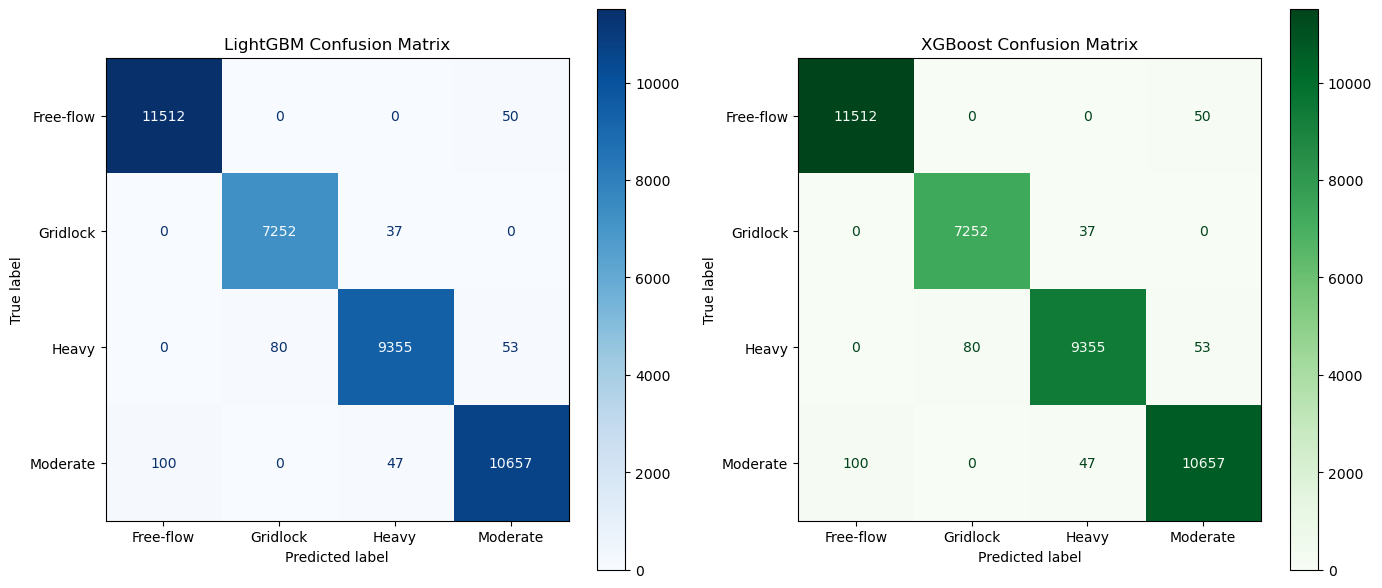


Models saved to /models/


In [19]:
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Final classification reports (tuned models)
print("=== Tuned LightGBM ===")
print(classification_report(y_test_f, lgb_best_preds, target_names=le.classes_))

print("=== Tuned XGBoost ===")
print(classification_report(y_test_f, xgb_best_preds, target_names=le.classes_))

# 2. Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay.from_predictions(y_test_f, lgb_best_preds, display_labels=le.classes_, ax=axes[0], cmap='Blues')
axes[0].set_title('LightGBM Confusion Matrix')
ConfusionMatrixDisplay.from_predictions(y_test_f, xgb_best_preds, display_labels=le.classes_, ax=axes[1], cmap='Greens')
axes[1].set_title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png')
plt.show()

# 3. Save models + label encoder for deployment
joblib.dump(lgb_best, '../models/lightgbm_model.pkl')
joblib.dump(xgb_best, '../models/xgboost_model.pkl')
joblib.dump(le, '../models/label_encoder.pkl')
joblib.dump(final_features_v2, '../models/feature_list.pkl')

print("\nModels saved to /models/")

In [20]:
import numpy as np

# 1. Get predicted probabilities from both tuned models
lgb_proba = lgb_best.predict_proba(X_test_f)
xgb_proba = xgb_best.predict_proba(X_test_f)

# 2. Weighted ensemble (test a couple of weight combinations)
weight_combinations = [(0.5, 0.5), (0.55, 0.45), (0.6, 0.4), (0.45, 0.55)]

for w_lgb, w_xgb in weight_combinations:
    ensemble_proba = (w_lgb * lgb_proba) + (w_xgb * xgb_proba)
    ensemble_preds = np.argmax(ensemble_proba, axis=1)
    acc = accuracy_score(y_test_f, ensemble_preds)
    f1 = f1_score(y_test_f, ensemble_preds, average='macro')
    print(f"LGBM={w_lgb}, XGB={w_xgb} -> Accuracy: {acc:.4f}, F1(macro): {f1:.4f}")

# 3. Pick best weight combo based on above, then finalize
best_w_lgb, best_w_xgb = 0.5, 0.5  # <-- update this after seeing results above
final_ensemble_proba = (best_w_lgb * lgb_proba) + (best_w_xgb * xgb_proba)
final_ensemble_preds = np.argmax(final_ensemble_proba, axis=1)

print("\n=== Final Ensemble Performance ===")
print("Accuracy:", accuracy_score(y_test_f, final_ensemble_preds))
print("F1 (macro):", f1_score(y_test_f, final_ensemble_preds, average='macro'))
print(classification_report(y_test_f, final_ensemble_preds, target_names=le.classes_))

LGBM=0.5, XGB=0.5 -> Accuracy: 0.9906, F1(macro): 0.9906
LGBM=0.55, XGB=0.45 -> Accuracy: 0.9906, F1(macro): 0.9906
LGBM=0.6, XGB=0.4 -> Accuracy: 0.9906, F1(macro): 0.9906
LGBM=0.45, XGB=0.55 -> Accuracy: 0.9906, F1(macro): 0.9906

=== Final Ensemble Performance ===
Accuracy: 0.9906241218097744
F1 (macro): 0.9906166352483599
              precision    recall  f1-score   support

   Free-flow       0.99      1.00      0.99     11562
    Gridlock       0.99      0.99      0.99      7289
       Heavy       0.99      0.99      0.99      9488
    Moderate       0.99      0.99      0.99     10804

    accuracy                           0.99     39143
   macro avg       0.99      0.99      0.99     39143
weighted avg       0.99      0.99      0.99     39143



In [21]:
import json

# 1. Save ensemble weights config
ensemble_config = {
    'weight_lgb': 0.5,
    'weight_xgb': 0.5,
    'features': final_features_v2
}

with open('../models/ensemble_config.json', 'w') as f:
    json.dump(ensemble_config, f, indent=4)

print("Ensemble config saved.")

# 2. Build a reusable prediction function (this will be imported into src/predict.py later)
def predict_traffic_demand(input_df, lgb_model, xgb_model, label_encoder, feature_list, w_lgb=0.5, w_xgb=0.5):
    """
    input_df: pandas DataFrame with the same raw columns as training data (pre-feature-engineering)
    Returns: predicted label (string) and class probabilities
    """
    X_input = input_df[feature_list]
    lgb_p = lgb_model.predict_proba(X_input)
    xgb_p = xgb_model.predict_proba(X_input)
    ensemble_p = (w_lgb * lgb_p) + (w_xgb * xgb_p)
    pred_class = np.argmax(ensemble_p, axis=1)
    pred_label = label_encoder.inverse_transform(pred_class)
    return pred_label, ensemble_p

# 3. Quick sanity test on a few test rows
sample_input = X_test_f.iloc[:5]
sample_labels, sample_probs = predict_traffic_demand(sample_input, lgb_best, xgb_best, le, final_features_v2)
print("\nSample predictions:", sample_labels)
print("Actual labels:", le.inverse_transform(y_test_f.iloc[:5].values))

Ensemble config saved.

Sample predictions: ['Moderate' 'Free-flow' 'Heavy' 'Moderate' 'Heavy']
Actual labels: ['Moderate' 'Free-flow' 'Heavy' 'Moderate' 'Heavy']


In [22]:
import sys
sys.path.append('../src')
from data_preprocessing import load_and_clean_data
from feature_engineering import engineer_features, FINAL_FEATURES

df_test = load_and_clean_data('../data/raw/vanet_traffic_data.csv')
df_test, road_freq = engineer_features(df_test)
print(df_test[FINAL_FEATURES].head())
print("\nModule test passed.")

   congestion_pressure  weather_factor  incident_num  channel_busy_ratio_pct  \
0               5.0977        156.3778         0.510                   29.96   
1             108.1477         20.1982         2.088                   88.28   
2               5.2396        150.1454         0.437                   28.90   
3               8.1846        149.7671         0.467                   31.38   
4               0.4169        259.8905         0.000                    7.83   

   occupancy_pct  avg_speed_kmph  flow_veh_per_hr  speed_density_ratio  \
0          39.85           43.38          1463.49               1.7504   
1          95.67            4.50           105.16               0.0502   
2          42.26           45.68          1536.62               1.5510   
3          34.66           44.34          1486.33               1.4700   
4          12.45           66.86          1954.74              12.6102   

   packet_loss_pct  wireless_congestion_intensity  queue_length_veh  \
0  

In [23]:
import sys
sys.path.append('../src')
from train import train_pipeline

lgb_m, xgb_m, le_m = train_pipeline()

LightGBM Test Accuracy: 0.9906241218097744
XGBoost Test Accuracy: 0.9906241218097744

All artifacts saved to ../models/


In [24]:
import sys
sys.path.append('../src')
from predict import TrafficDemandPredictor

predictor = TrafficDemandPredictor(model_dir='../models/')

# Use a real row from your raw data for a sanity test
sample_row = df.iloc[0].to_dict()
pred_label, probs = predictor.predict_from_raw_row(sample_row)

print("Predicted label:", pred_label)
print("Probabilities:", probs)
print("Actual label:", sample_row['label'])

Predicted label: Moderate
Probabilities: {'Free-flow': np.float64(0.00672269529769977), 'Gridlock': np.float64(0.001499708649415224), 'Heavy': np.float64(0.0065274499643348995), 'Moderate': np.float64(0.9852501384537968)}
Actual label: Moderate
